In [17]:
import pandas as pd 
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


#.\Prueba_2\Scripts\activate

In [18]:
report = pd.read_csv("Call_center_metrics.csv")

In [19]:
report.tail()


,Sort,Dates,"Average Number of Operators, Mon-Fri, (7:00AM-3:00PM)","Average Number of Operators, Mon-Fri, (3:00PM-11:00PM)","Average Number of Operators, Mon-Fri, (11:00PM-7:00AM)","Average Number of Operators, Sat-Sun, (7:00AM-3:00PM)","Average Number of Operators, Sat-Sun, (3:00PM-11:00PM)","Average Number of Operators, Sat-Sun, (11:00PM-7:00AM)",Call Volume (7:00AM-3:00PM),Call Volume (3:00PM-11:00PM),...,Efficiency (11:00PM-7:00AM),Utilization (7:00AM-3:00PM),Utilization (3:00PM-11:00PM),Utilization (11:00PM-7:00AM),Abandoned (7:00AM-3:00PM),Abandoned (3:00PM-11:00PM),Abandoned (11:00PM-7:00AM),Average Wait Time (seconds): 7:00AM-3:00PM,Average Wait Time (seconds): 3:00PM-11:00PM,Average Wait Time (seconds): 11:00PM-7:00AM
265,266,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
266,267,7/4/16 - 7/10/16,18.0,10.0,2.0,12.0,9.0,2.0,35083.0,25567.0,...,91.0,72.0,74.0,49.0,21.0,13.0,12.0,104.0,37.0,13.0
267,268,7/11/16- 7/17/16,18.0,11.0,3.0,12.0,7.0,1.0,37621.0,26681.0,...,93.0,77.0,76.0,39.0,22.0,16.0,8.0,107.0,53.0,7.0
268,269,7/18/16- 7/24/16,18.0,9.0,2.0,10.0,8.0,2.0,39145.0,38300.0,...,88.0,78.0,77.0,48.0,21.0,37.0,15.0,102.0,128.0,23.0
269,270,7/25/16 - 7/31/16,19.0,8.0,2.0,11.0,7.0,3.0,44804.0,30477.0,...,91.0,81.0,80.0,45.0,28.0,24.0,10.0,119.0,100.0,17.0


In [20]:
report.info()

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 23 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Sort                                                     270 non-null    int64  
 1   Dates                                                    268 non-null    str    
 2   Average Number of Operators, Mon-Fri, (7:00AM-3:00PM)    268 non-null    float64
 3   Average Number of Operators, Mon-Fri, (3:00PM-11:00PM)   268 non-null    float64
 4   Average Number of Operators, Mon-Fri, (11:00PM-7:00AM)   268 non-null    float64
 5   Average Number of Operators, Sat-Sun, (7:00AM-3:00PM)    268 non-null    float64
 6   Average Number of Operators, Sat-Sun, (3:00PM-11:00PM)   268 non-null    float64
 7   Average Number of Operators, Sat-Sun, (11:00PM-7:00AM)   268 non-null    float64
 8   Call Volume (7:00AM-3:00PM)              

## Data correction

In [21]:
# Primer forma de hacerlo, mas larga.


#report["Start_Date"]= report["Dates"].str.split("-").str[0].str.strip()
#report["End_Date"]= report["Dates"].str.split("-").str[1].str.strip()
#report["Start_Date"] = pd.to_datetime(report["Start_Date"], format="%m/%d/%y")
#report[report["End_Date"].str.contains("0608/14", na=False)]
#report["End_Date"]=report["End_Date"].str.replace("0608/14", "06/08/14",)
#report["End_Date"] = pd.to_datetime(report["End_Date"], errors="coerce", format="%m/%d/%y")


#report[["Start_Date","End_Date"]] = report[["Start_Date","End_Date"]].apply(lambda x: x.str.strip()) # remove leading and trailing whitespace from the "Start_Date" and "End_Date" columns using the apply method with a lambda function that applies the str.strip() method to each column.

In [22]:
#Segunda forma de hacerlo.


report[["Start_Date","End_Date"]] = report["Dates"].str.split("-", n=1, expand=True) # split the "Dates" column into "Start_Date" and "End_Date" columns, splitting at the first occurrence of "-"
#n=1 ensures that only the first "-" is used for splitting, which is important if there are multiple "-" in the "Dates" column. expand=True creates separate columns for the split values.
#Example:
#texto = "A-B-C-D-E-F-G"
#texto.split("-", 2)
#['A', 'B', 'C-D-E-F-G']

report["Start_Date"] = report["Start_Date"].str.strip()
report["End_Date"] = report["End_Date"].str.strip()

report["Start_Date"] = pd.to_datetime(report["Start_Date"], format="%m/%d/%y")
report["End_Date"] = pd.to_datetime(report["End_Date"], errors="coerce", format="%m/%d/%y")





#report[["Start_Date","End_Date"]] = report[["Start_Date","End_Date"]].apply(lambda x: x.str.strip()) # remove leading and trailing whitespace from the "Start_Date" and "End_Date" columns using the apply method with a lambda function that applies the str.strip() method to each column.

In [23]:
report.columns = report.columns.str.strip()

In [24]:
report.rename(columns={'Average Number of Operators, Mon-Fri, (7:00AM-3:00PM)': 'avg_operators_mon_fri_7_3',
                       'Average Number of Operators, Mon-Fri, (3:00PM-11:00PM)': 'avg_operators_mon_fri_3_11',
                          'Average Number of Operators, Mon-Fri, (11:00PM-7:00AM)': 'avg_operators_mon_fri_11_7',
                            'Average Number of Operators, Sat-Sun, (7:00AM-3:00PM)': 'avg_operators_sat_sun_7_3',
                                'Average Number of Operators, Sat-Sun, (3:00PM-11:00PM)': 'avg_operators_sat_sun_3_11',
                                    'Average Number of Operators, Sat-Sun, (11:00PM-7:00AM)': 'avg_operators_sat_sun_11_7',
                                    'Call Volume (7:00AM-3:00PM)': 'call_volume_7_3',
                                    'Call Volume (3:00PM-11:00PM)': 'call_volume_3_11',
                                    'Call Volume (11:00PM-7:00AM)': 'call_volume_11_7',
                                    'Efficiency (7:00AM-3:00PM)': 'efficiency_7_3',
                                    'Efficiency (3:00PM-11:00PM)': 'efficiency_3_11',
                                    'Efficiency (11:00PM-7:00AM)': 'efficiency_11_7', 
                                    'Utilization (7:00AM-3:00PM)': 'utilization_7_3',
                                    'Utilization (3:00PM-11:00PM)': 'utilization_3_11',
                                    'Utilization (11:00PM-7:00AM)': 'utilization_11_7',
                                    'Abandoned (7:00AM-3:00PM)': 'abandoned_7_3',
                                    'Abandoned (3:00PM-11:00PM)': 'abandoned_3_11',
                                    'Abandoned (11:00PM-7:00AM)': 'abandoned_11_7',
                                    'Average Wait Time (seconds): 7:00AM-3:00PM': 'avg_wait_time_7_3',
                                    'Average Wait Time (seconds): 3:00PM-11:00PM': 'avg_wait_time_3_11',
                                    'Average Wait Time (seconds): 11:00PM-7:00AM': 'avg_wait_time_11_7'}, inplace=True)

In [25]:
report.columns = report.columns.str.lower()
report = report.set_index("sort")

## Clear empty values and fix duplicate values

In [26]:
report.isnull().sum()       

dates                         2
avg_operators_mon_fri_7_3     2
avg_operators_mon_fri_3_11    2
avg_operators_mon_fri_11_7    2
avg_operators_sat_sun_7_3     2
avg_operators_sat_sun_3_11    2
avg_operators_sat_sun_11_7    2
call_volume_7_3               2
call_volume_3_11              2
call_volume_11_7              2
efficiency_7_3                2
efficiency_3_11               2
efficiency_11_7               2
utilization_7_3               2
utilization_3_11              2
utilization_11_7              2
abandoned_7_3                 2
abandoned_3_11                2
abandoned_11_7                2
avg_wait_time_7_3             2
avg_wait_time_3_11            2
avg_wait_time_11_7            3
start_date                    2
end_date                      5
dtype: int64

In [27]:
report.dropna(inplace=True)
report.isnull().sum()    

dates                         0
avg_operators_mon_fri_7_3     0
avg_operators_mon_fri_3_11    0
avg_operators_mon_fri_11_7    0
avg_operators_sat_sun_7_3     0
avg_operators_sat_sun_3_11    0
avg_operators_sat_sun_11_7    0
call_volume_7_3               0
call_volume_3_11              0
call_volume_11_7              0
efficiency_7_3                0
efficiency_3_11               0
efficiency_11_7               0
utilization_7_3               0
utilization_3_11              0
utilization_11_7              0
abandoned_7_3                 0
abandoned_3_11                0
abandoned_11_7                0
avg_wait_time_7_3             0
avg_wait_time_3_11            0
avg_wait_time_11_7            0
start_date                    0
end_date                      0
dtype: int64

NaN values were deleted

In [28]:
report.duplicated().sum()

np.int64(0)

No duplicate values


#

## a


In [29]:
report

,dates,avg_operators_mon_fri_7_3,avg_operators_mon_fri_3_11,avg_operators_mon_fri_11_7,avg_operators_sat_sun_7_3,avg_operators_sat_sun_3_11,avg_operators_sat_sun_11_7,call_volume_7_3,call_volume_3_11,call_volume_11_7,...,utilization_3_11,utilization_11_7,abandoned_7_3,abandoned_3_11,abandoned_11_7,avg_wait_time_7_3,avg_wait_time_3_11,avg_wait_time_11_7,start_date,end_date
sort,,,,,,,,,,,,,,,,,,,,,
1,4/10/11-4/16/11,2.0,25.0,8.0,2.0,16.0,7.0,3905.0,27090.0,18113.0,...,74.0,69.0,9.0,11.0,17.0,14.0,53.0,67.0,2011-04-10,2011-04-16
2,4/17/11-4/23/11,2.0,24.0,7.0,1.0,15.0,7.0,3892.0,27021.0,16865.0,...,75.0,71.0,6.0,12.0,16.0,8.0,12.0,72.0,2011-04-17,2011-04-23
3,4/24/11-4/30/11,2.0,25.0,10.0,2.0,15.0,8.0,3748.0,26995.0,18266.0,...,73.0,69.0,8.0,9.0,14.0,10.0,41.0,51.0,2011-04-24,2011-04-30
4,5/1/11-5/7/11,2.0,22.0,10.0,2.0,15.0,9.0,4167.0,26105.0,18029.0,...,74.0,66.0,8.0,12.0,13.0,11.0,63.0,51.0,2011-05-01,2011-05-07
5,5/8/11-5/14/11,2.0,22.0,9.0,2.0,12.0,9.0,4385.0,24762.0,18171.0,...,76.0,71.0,10.0,17.0,17.0,13.0,105.0,69.0,2011-05-08,2011-05-14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,6/20/16-6/26/16,20.0,9.0,2.0,10.0,8.0,3.0,35700.0,27753.0,4605.0,...,76.0,42.0,16.0,16.0,10.0,71.0,48.0,10.0,2016-06-20,2016-06-26
267,7/4/16 - 7/10/16,18.0,10.0,2.0,12.0,9.0,2.0,35083.0,25567.0,5393.0,...,74.0,49.0,21.0,13.0,12.0,104.0,37.0,13.0,2016-07-04,2016-07-10
268,7/11/16- 7/17/16,18.0,11.0,3.0,12.0,7.0,1.0,37621.0,26681.0,4383.0,...,76.0,39.0,22.0,16.0,8.0,107.0,53.0,7.0,2016-07-11,2016-07-17


In [30]:
report[["call_volume_7_3", "call_volume_3_11", "call_volume_11_7"]].mean().round(2) 
# This indicates the average call volume for eacg time period, which can help the call center to allocate resources effectively and plan for peak call times.

call_volume_7_3     31579.39
call_volume_3_11    22716.50
call_volume_11_7     4548.92
dtype: float64

In [31]:
report[["abandoned_7_3", "abandoned_3_11", "abandoned_11_7"]].mean().round(2)
# This indicates the average number of abandoned calls for each time period, which can help the call center to identify potential issues with wait times or staffing levels during those periods.

abandoned_7_3     14.80
abandoned_3_11    14.53
abandoned_11_7     9.20
dtype: float64

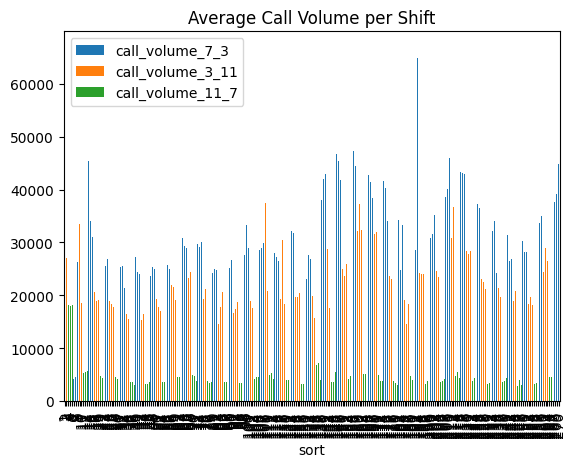

In [33]:
report[["call_volume_7_3", "call_volume_3_11", "call_volume_11_7"]].plot(kind="bar")

plt.title("Average Call Volume per Shift")
plt.show()